In [1]:
import sys, itertools, time
sys.path.insert(0, 'experiment_utils')
from _slurm import parse_slurm_task

PARAMETER_GRID = [
    {"seed": s, "test_idx": t}
    for s, t in itertools.product([42, 123, 7], [0, 1, 2])
]
_params, _task_id = parse_slurm_task(PARAMETER_GRID)

# Physics Constraint Comparison: Electrical Impedance Tomography

- PDE: $-\nabla \cdot (a \nabla u) = 0$
- Latent dimension: $d_a = 6$ (MCMC), $d_u = 26$ (with boundary encoding)
- Observations: Neumann boundary flux

In [2]:
sys.path.insert(0, '..')
import load_this_before_everything_else

import jax
import jax.numpy as jnp
from jax import random, vmap
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value
from numpyro.diagnostics import effective_sample_size, split_gelman_rubin

from src.problems.eit import (
    EIT,
    one_hot_g_l,
    compute_u_and_grad_eit,
    mollifier_eit,
    compute_pde_residual_eit_single_sample,
)
from src.evaluation.metrics import rmse
from src.solver.config import InversionConfig, LossWeights, OptimizerConfig, SchedulerConfig

from experiment_utils import (
    crps_ensemble, compute_calibration, ci_width_95, nll_score,
    compute_prior_predictive, build_prior_result,
    plot_field_comparison, plot_calibration, plot_posterior_gallery,
    plot_posterior_predictive, plot_trace, plot_metrics_table,
    plot_rho_sweep, plot_std_comparison, plot_metrics_comparison_table,
    plot_eit_ground_truth, plot_eit_observation_data,
    plot_sharpness_calibration_tradeoff,
    bootstrap_metric_ci, compute_per_chain_metrics,
    bootstrap_metric_difference_ci, format_significance_table,
    tune_sigma, recommended_nuts_config, mcmc_reliability_flag,
    chi2_ppc,
    compute_metric_convergence, plot_metric_convergence,
    load_problem, get_nf_mode, make_log_prior,
    make_numpyro_model, make_numpyro_model_physics,
    run_map_estimation,
    run_mcmc, extract_mcmc_diagnostics,
    compute_standard_metrics,
    build_mcmc_result, save_experiment_result,
    compute_error_std_correlation,
    load_cross_seed_results, cross_seed_metric_summary,
    sample_unconditional_prior,
    plot_uncertainty_investigation,
    _use_science_style,
)

SEEDS = [42, 123, 7]
if _task_id is not None:
    SEEDS = [PARAMETER_GRID[_task_id]["seed"]]

TEST_IDX = 0
if _task_id is not None:
    TEST_IDX = PARAMETER_GRID[_task_id]["test_idx"]

print(f"JAX: {jax.__version__}, NumPyro: {numpyro.__version__}")
print(f"Devices: {jax.devices()}")

HIGH PRECISION MODE ACTIVATED!!!


JAX: 0.4.35, NumPyro: 0.19.0


Devices: [CudaDevice(id=0)]


## 1. Load Trained Model

In [3]:
CHECKPOINT_PATH = Path('../runs/final_eit/weights/best.pt')
TEST_DATA_PATH = '../data/eit/inverse_EIT_in.mat'

problem = EIT(seed=42, test_data_path=TEST_DATA_PATH)
params = load_problem(problem, CHECKPOINT_PATH)
beta_a_mode, d = get_nf_mode(problem, params)
log_prior_fn = make_log_prior(problem, params)

n_points = problem.get_n_points()

print(f"Latent dim (coeff): {problem.BETA_SIZE_A}")
print(f"Latent dim (combined): {problem.BETA_SIZE_U}")

Loading data...


  Test: a=(20, 1024, 1), u=[[[ 1.        ]
  [ 0.9797001 ]
  [ 0.9204757 ]
  ...
  [ 0.8746724 ]
  [ 0.761118  ]
  [ 0.6172527 ]]

 [[ 1.        ]
  [ 0.981173  ]
  [ 0.9261911 ]
  ...
  [ 0.3165446 ]
  [ 0.12906456]
  [-0.06325148]]

 [[ 1.        ]
  [ 0.98346853]
  [ 0.9351161 ]
  ...
  [-0.2334332 ]
  [-0.40426344]
  [-0.5620679 ]]

 ...

 [[ 1.        ]
  [ 0.981173  ]
  [ 0.9261911 ]
  ...
  [-0.8738502 ]
  [-0.7647962 ]
  [-0.62749803]]

 [[ 1.        ]
  [ 0.9797001 ]
  [ 0.9204757 ]
  ...
  [ 0.10988297]
  [ 0.30528814]
  [ 0.48864248]]

 [[ 1.        ]
  [ 0.9791928 ]
  [ 0.918509  ]
  ...
  [ 0.918509  ]
  [ 0.9791928 ]
  [ 1.        ]]]
  Boundary points: 124 (left=32, top=31, right=31, bottom=30)
Setting up grids and test functions...


  int_grid: (25, 2), v: (25, 1)
Building models...


  Initialized enc: 113,702 params


  Initialized u: 83,805 params
  Initialized a: 81,805 params


E0612 15:46:46.899917      24 hlo_lexer.cc:443] Failed to parse int literal: 894515288310727292233


  Initialized nf: 15,420 params
Loading checkpoint: ../runs/final_eit/weights/best.pt
  Loaded enc
  Loaded u
  Loaded a
  Loaded nf


Latent dim (coeff): 6
Latent dim (combined): 26


## 2. Config

In [4]:
N_OBS = 124  # All boundary points
NC_PDE = 50

RHO_PDE_VALUES = [2.0, 1.0, 0.5, 0.3, 0.15, 0.1, 0.07, 0.05]
SWEEP_WARMUP = 1000
SWEEP_SAMPLES = 500

NUM_WARMUP = 5000
NUM_SAMPLES = 2000
NUM_CHAINS = 4
CHAIN_METHOD = 'vectorized'
SAMPLE_NAME = 'beta_a'

inv_config = InversionConfig(
    epochs=200,
    loss_weights=LossWeights(pde=1.0, data=100.0),
    optimizer=OptimizerConfig(type='Adam', lr=0.01),
    scheduler=SchedulerConfig(type='StepLR', step_size=25, gamma=0.25),
)

## 3. Fixed PDE Collocation Points

In [5]:
pde_rng = random.PRNGKey(123)
xc_fixed, R_fixed = problem.genPoint.weight_centers(
    n_center=NC_PDE, R_max=1e-4, R_min=1e-4, key=pde_rng,
)
x_pde_fixed = (problem.int_grid[None, :, :] * R_fixed + xc_fixed).reshape(-1, 2)

print(f"Fixed PDE grid: {x_pde_fixed.shape}  ({NC_PDE} centers x {problem.n_grid} pts)")


def log_pde_fn(beta_a, rho_pde):
    """PDE virtual-observable log-likelihood for EIT (source = 0)."""
    beta_b = beta_a[None, :]
    g_l_onehot = one_hot_g_l(problem._current_g_l)
    beta_u = jnp.concatenate([beta_b, g_l_onehot], axis=-1)

    x_pde_b = x_pde_fixed[None, :, :]
    a_decoded = problem.models['a'].apply({'params': params['a']}, x_pde_b, beta_b)
    a_vals = a_decoded[0, :, None]

    g_l_scalar = problem._current_g_l[0, 0]
    residuals = compute_pde_residual_eit_single_sample(
        params['u'], problem.models['u'], beta_u[0], g_l_scalar,
        xc_fixed, R_fixed, problem.int_grid, problem.v, problem.dv_dr,
        a_vals, problem.n_grid,
    )
    return -0.5 * jnp.sum(residuals ** 2) / (rho_pde ** 2)

Fixed PDE grid: (1250, 2)  (50 centers x 25 pts)


## 4. Sigma Tuning (seed-42 observations)

In [6]:
_rng_setup = random.PRNGKey(42)
_rng_setup, _key = random.split(_rng_setup)

_obs_indices_tune = problem.sample_observation_indices(n_points, N_OBS, 'random', _key)
_obs_data_tune = problem.prepare_observations(
    sample_indices=[TEST_IDX], obs_indices=_obs_indices_tune,
)
_x_full_tune = _obs_data_tune['x_full']
_x_obs_tune = _obs_data_tune['x_obs']
_u_obs_tune = _obs_data_tune['u_obs']
_a_true_tune = _obs_data_tune['a_true']
_g_l_tune = _obs_data_tune['g_l']
_normals_tune = problem._active_boundary_normals_jax


def _make_eit_log_likelihood(x_obs, u_obs, normals):
    """Factory for EIT Neumann flux log-likelihood (closes over obs)."""
    def log_likelihood_fn(beta_a, sigma):
        beta_b = beta_a[None, :]
        g_l_onehot = one_hot_g_l(problem._current_g_l)
        beta_u = jnp.concatenate([beta_b, g_l_onehot], axis=-1)
        g_l_scalar = problem._current_g_l[0, 0]
        _, du_vals = compute_u_and_grad_eit(
            params['u'], problem.models['u'],
            x_obs[0], beta_u[0], g_l_scalar
        )
        a_vals = problem.models['a'].apply(
            {'params': params['a']}, x_obs, beta_b
        )[0]
        neumann_pred = a_vals * (du_vals[:, 0] * normals[:, 0] + du_vals[:, 1] * normals[:, 1])
        neumann_obs = u_obs[0, :, 0]
        sq_err = jnp.sum((neumann_pred - neumann_obs) ** 2)
        n = neumann_obs.shape[0]
        return -0.5 * sq_err / (sigma ** 2) - 0.5 * n * jnp.log(2 * jnp.pi * sigma ** 2)
    return log_likelihood_fn


_log_lik_tune = _make_eit_log_likelihood(_x_obs_tune, _u_obs_tune, _normals_tune)
_numpyro_model_tune = make_numpyro_model(d, log_prior_fn, _log_lik_tune, sample_name=SAMPLE_NAME)


def _model_factory_tune(sigma):
    def _model():
        _numpyro_model_tune(sigma=sigma)
    return _model


def _decode_fn_tune(beta_samples):
    a_preds = []
    x_full_tiled = jnp.tile(_x_full_tune, (1, 1, 1))
    for i in range(len(beta_samples)):
        beta_i = beta_samples[i:i+1]
        a_pred = problem.models['a'].apply({'params': params['a']}, x_full_tiled, jnp.array(beta_i))
        a_preds.append(np.array(a_pred[0]))
    return np.stack(a_preds)


_rng_setup, _tune_key = random.split(_rng_setup)
SIGMA, _ = tune_sigma(
    model_fn_factory=_model_factory_tune,
    beta_mode=beta_a_mode,
    sigma_candidates=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
    rng_key=_tune_key,
    decode_fn=_decode_fn_tune,
    a_true=np.array(_a_true_tune[0, :, 0]),
    pilot_warmup=2000,
    pilot_samples=500,
    pilot_chains=2,
    sample_name=SAMPLE_NAME,
)
print(f"Sigma (tuned): {SIGMA:.6f}")

  Sigma tuning (6 candidates, 2000 warmup + 500 samples × 2 chains):


    sigma=0.1000  cov=0.872  ESS_min=311.0  R-hat=1.010  div=0  OK


    sigma=0.2000  cov=0.994  ESS_min=75.2  R-hat=1.019  div=20  OK


    sigma=0.3000  cov=0.989  ESS_min=139.7  R-hat=1.017  div=7  OK


    sigma=0.4000  cov=0.996  ESS_min=252.2  R-hat=1.010  div=3  OK


    sigma=0.5000  cov=0.998  ESS_min=283.5  R-hat=1.003  div=7  OK


    sigma=0.6000  cov=1.000  ESS_min=322.6  R-hat=1.009  div=15  OK
  Selected sigma=0.1  (coverage=0.872, ESS_min=311.0)
Sigma (tuned): 0.100000


## 5. rho_pde Sweep (outside seed loop)

In [7]:
# Data-only sweep baseline
_rng_setup, _sweep_do_key = random.split(_rng_setup)
nuts_cfg_sweep = recommended_nuts_config(d, SIGMA)
_kernel_sweep_do = NUTS(
    _numpyro_model_tune,
    init_strategy=init_to_value(values={SAMPLE_NAME: beta_a_mode}),
    target_accept_prob=nuts_cfg_sweep['target_accept_prob'],
    max_tree_depth=nuts_cfg_sweep['max_tree_depth'],
    dense_mass=nuts_cfg_sweep.get('dense_mass', False),
)
_mcmc_sweep_do = MCMC(_kernel_sweep_do, num_warmup=SWEEP_WARMUP, num_samples=SWEEP_SAMPLES,
                      num_chains=1, progress_bar=True)
_mcmc_sweep_do.run(_sweep_do_key, sigma=SIGMA, extra_fields=('diverging',))

_beta_a_sweep_do = _mcmc_sweep_do.get_samples()[SAMPLE_NAME]
_n_sweep_do = _beta_a_sweep_do.shape[0]
_x_tile_sweep = jnp.tile(_x_full_tune, (_n_sweep_do, 1, 1))
_a_pred_sweep_do = problem.models['a'].apply({'params': params['a']}, _x_tile_sweep, _beta_a_sweep_do)
_a_pred_sweep_do = _a_pred_sweep_do[..., None] if _a_pred_sweep_do.ndim == 2 else _a_pred_sweep_do
_a_mean_sweep_do = jnp.mean(_a_pred_sweep_do, axis=0)
_a_err_sweep_do = float(
    jnp.linalg.norm(_a_mean_sweep_do[:, 0] - _a_true_tune[0, :, 0]) /
    jnp.linalg.norm(_a_true_tune[0, :, 0])
)
_a_lo_sweep_do = jnp.percentile(_a_pred_sweep_do, 2.5, axis=0)
_a_hi_sweep_do = jnp.percentile(_a_pred_sweep_do, 97.5, axis=0)
_coverage_sweep_do = float(((jnp.array(_a_true_tune[0]) >= _a_lo_sweep_do) & (jnp.array(_a_true_tune[0]) <= _a_hi_sweep_do)).mean())
_ci_width_sweep_do = float(jnp.mean(_a_hi_sweep_do - _a_lo_sweep_do))
_mean_std_sweep_do = float(jnp.mean(jnp.std(_a_pred_sweep_do[:, :, 0], axis=0)))
_sweep_data_only_baseline = {
    'a_err': _a_err_sweep_do,
    'coverage': _coverage_sweep_do,
    'ci_width': _ci_width_sweep_do,
    'mean_std': _mean_std_sweep_do,
}
print(f"Sweep data-only baseline a_err = {_a_err_sweep_do:.4f}")

  0%|          | 0/1500 [00:00<?, ?it/s]

warmup:   0%|          | 1/1500 [00:06<2:32:56,  6.12s/it, 1 steps of size 2.13e+00. acc. prob=0.00]

warmup:   1%|          | 11/1500 [00:06<10:55,  2.27it/s, 511 steps of size 1.03e-04. acc. prob=0.52]

warmup:   2%|▏         | 27/1500 [00:06<03:33,  6.91it/s, 3 steps of size 1.68e-04. acc. prob=0.70]  

warmup:   2%|▏         | 37/1500 [00:06<02:17, 10.61it/s, 15 steps of size 1.96e-04. acc. prob=0.74]

...

sample:  99%|█████████▊| 1479/1500 [00:32<00:00, 74.75it/s, 15 steps of size 1.86e-01. acc. prob=0.95]

sample:  99%|█████████▉| 1489/1500 [00:32<00:00, 78.77it/s, 15 steps of size 1.86e-01. acc. prob=0.95]

sample: 100%|█████████▉| 1498/1500 [00:32<00:00, 80.40it/s, 7 steps of size 1.86e-01. acc. prob=0.95] 

sample: 100%|██████████| 1500/1500 [00:32<00:00, 45.53it/s, 31 steps of size 1.86e-01. acc. prob=0.95]

Sweep data-only baseline a_err = 0.0044


In [8]:
_numpyro_model_physics_sweep = make_numpyro_model_physics(d, log_prior_fn, _log_lik_tune, log_pde_fn, sample_name=SAMPLE_NAME)


def _run_sweep_one(rho_pde, warmup, n_samples, rng_key):
    """Run NUTS for one rho_pde value (using seed-42 obs), return metrics dict."""
    nuts_cfg = recommended_nuts_config(d, SIGMA)
    kernel = NUTS(
        _numpyro_model_physics_sweep,
        init_strategy=init_to_value(values={SAMPLE_NAME: beta_a_mode}),
        target_accept_prob=nuts_cfg['target_accept_prob'],
        max_tree_depth=nuts_cfg['max_tree_depth'],
        dense_mass=nuts_cfg.get('dense_mass', False),
    )
    mcmc = MCMC(kernel, num_warmup=warmup, num_samples=n_samples,
                num_chains=1, chain_method=CHAIN_METHOD, progress_bar=True)
    _t_pilot = time.time()
    mcmc.run(rng_key, sigma=SIGMA, rho_pde=rho_pde, extra_fields=('diverging',))
    print(f"  Pilot completed in {time.time() - _t_pilot:.1f}s")

    beta_s = mcmc.get_samples()[SAMPLE_NAME]
    n_div = int(mcmc.get_extra_fields()['diverging'].sum())

    beta_by_chain = np.array(beta_s)[None, :, :]
    ess_min = float(effective_sample_size(beta_by_chain).min())

    _a_true_np_t = np.array(_a_true_tune[0, :, 0])
    n_s = beta_s.shape[0]
    x_tile = jnp.tile(_x_full_tune, (n_s, 1, 1))
    a_pred = problem.models['a'].apply({'params': params['a']}, x_tile, beta_s)
    a_pred = a_pred[..., None] if a_pred.ndim == 2 else a_pred

    a_samples_np = np.array(a_pred[:, :, 0])
    metrics = compute_standard_metrics(a_samples_np, _a_true_np_t)
    flag, _ = mcmc_reliability_flag(ess_min, 1.0, n_div, n_samples)

    return {
        "rho_pde": rho_pde,
        "a_err": metrics['a_err'],
        "u_err": 0.0,
        "coverage": metrics['coverage_95'],
        "ess_min": ess_min,
        "n_div": n_div,
        "crps_a": metrics['crps_a'],
        "nll_a": metrics['nll_a'],
        "ci_width": metrics['ci_width'],
        "mean_std": metrics['mean_std'],
        "rhat_max": None,
        "rhat_mean": None,
        "reliability_flag": flag,
    }

In [9]:
print(f"Screening sweep: {SWEEP_WARMUP} warmup, {SWEEP_SAMPLES} samples per rho")
print(f"rho values: {RHO_PDE_VALUES}")

sweep_results = []
for rho in RHO_PDE_VALUES:
    print(f"\n{'='*60}")
    print(f"rho_pde = {rho}")
    print(f"{'='*60}")
    _rng_setup, key = random.split(_rng_setup)
    res = _run_sweep_one(rho, SWEEP_WARMUP, SWEEP_SAMPLES, key)
    sweep_results.append(res)
    print(f"  a_err={res['a_err']:.4f}  "
          f"coverage={res['coverage']:.2%}  ESS_min={res['ess_min']:.1f}  "
          f"n_div={res['n_div']}  CRPS_a={res['crps_a']:.6f}")

Screening sweep: 1000 warmup, 500 samples per rho
rho values: [2.0, 1.0, 0.5, 0.3, 0.15, 0.1, 0.07, 0.05]

rho_pde = 2.0


  0%|          | 0/1500 [00:00<?, ?it/s]

warmup:   0%|          | 1/1500 [00:07<3:05:17,  7.42s/it, 1 steps of size 2.13e+00. acc. prob=0.00]

warmup:   1%|          | 12/1500 [00:07<11:21,  2.18it/s, 127 steps of size 1.12e-04. acc. prob=0.55]

warmup:   1%|▏         | 19/1500 [00:07<06:18,  3.91it/s, 63 steps of size 3.86e-04. acc. prob=0.67] 

...

sample: 100%|█████████▉| 1499/1500 [24:06<00:00,  1.00it/s, 1023 steps of size 3.21e-09. acc. prob=0.84]

sample: 100%|██████████| 1500/1500 [24:07<00:00,  1.00it/s, 1023 steps of size 3.21e-09. acc. prob=0.84]

sample: 100%|██████████| 1500/1500 [24:07<00:00,  1.04it/s, 1023 steps of size 3.21e-09. acc. prob=0.84]

  Pilot completed in 1449.0s


  a_err=0.0931  coverage=0.00%  ESS_min=3.2  n_div=0  CRPS_a=0.287042


In [10]:
header = f"{'rho_pde':>10} {'a_err':>8} {'coverage':>10} {'ESS_min':>9} {'n_div':>6} {'CRPS_a':>10}"
print(header)
print("-" * len(header))
print(f"{'inf (DO)':>10}  {_a_err_sweep_do:>7.4f}  {'N/A':>9}  {'N/A':>8}  {'N/A':>5}  {'N/A':>9}")
for r in sweep_results:
    print(f"{r['rho_pde']:>10.2f}  {r['a_err']:>7.4f}  "
          f"{r['coverage']:>9.2%}  {r['ess_min']:>8.1f}  {r['n_div']:>5}  {r['crps_a']:>9.6f}")

   rho_pde    a_err   coverage   ESS_min  n_div     CRPS_a
----------------------------------------------------------
  inf (DO)   0.0044        N/A       N/A    N/A        N/A
      2.00   0.0046     85.55%     212.9      0   0.010320
      1.00   0.0047     85.16%     246.6      0   0.010442
      0.50   0.0045     85.84%     328.5      0   0.010230
      0.30   0.0044     86.43%     232.9      0   0.009871
      0.15   0.0042     84.86%     261.2      0   0.009368
      0.10   0.0041     81.25%     243.8      0   0.009123
      0.07   0.0043     75.39%     171.1      0   0.009767
      0.05   0.0931      0.00%       3.2      0   0.287042


In [11]:
_a_err_threshold = _a_err_sweep_do * 2
candidates = [(abs(r['coverage'] - 0.95), r) for r in sweep_results
              if r['a_err'] <= _a_err_threshold]

if candidates:
    candidates.sort(key=lambda x: x[0])
    _best = candidates[0][1]
    BEST_RHO_PDE = _best['rho_pde']
    print(f"Best rho_pde = {BEST_RHO_PDE}")
    print(f"  a_err    = {_best['a_err']:.4f}  (baseline: {_a_err_sweep_do:.4f})")
    print(f"  coverage = {_best['coverage']:.2%}  (ideal: 95%)")
else:
    print("No candidate with a_err <= 2x baseline.")
    print("Setting BEST_RHO_PDE to largest value (weakest physics).")
    BEST_RHO_PDE = max(RHO_PDE_VALUES)

print(f"\nBEST_RHO_PDE = {BEST_RHO_PDE}")

Best rho_pde = 0.3
  a_err    = 0.0044  (baseline: 0.0044)
  coverage = 86.43%  (ideal: 95%)

BEST_RHO_PDE = 0.3


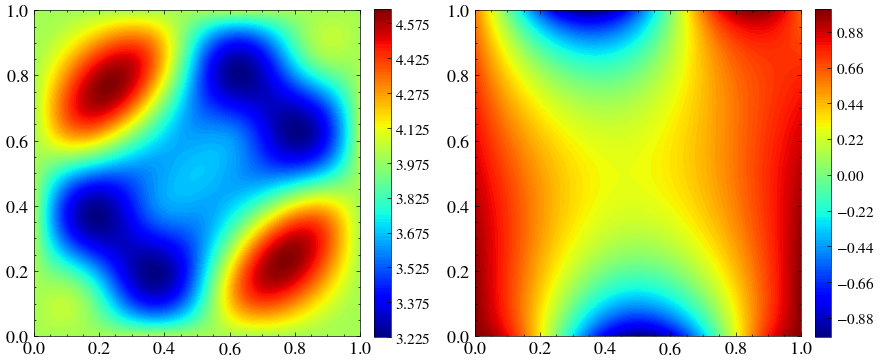

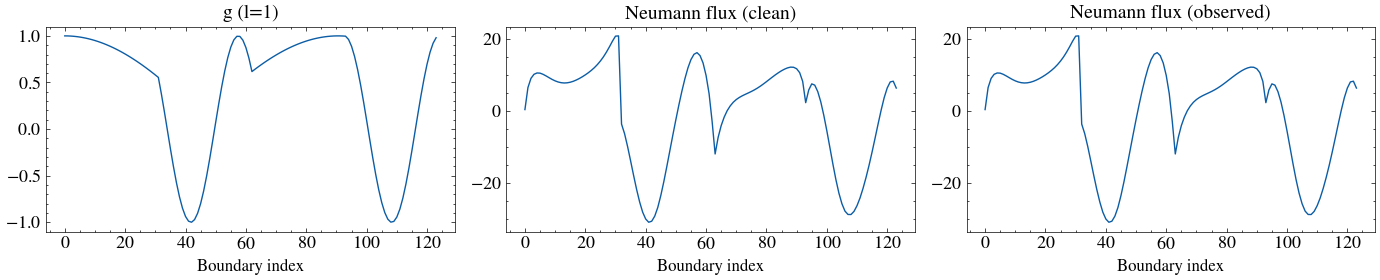

In [12]:
# Ground truth plots (using tuning obs)
plot_eit_ground_truth(
    np.array(_x_full_tune[0]),
    np.array(_a_true_tune[0, :, 0]),
    u_true=np.array(_obs_data_tune.get('u_true', [None])[0][:, 0]) if _obs_data_tune.get('u_true') is not None else None,
    save_path=Path('figures/physics_eit') / 'ground_truth.png',
)
plot_eit_observation_data(
    x_bd=np.array(_x_obs_tune[0]),
    g_l=int(_g_l_tune[0, 0]),
    neumann_obs=np.array(_u_obs_tune[0, :, 0]),
    save_path=Path('figures/physics_eit') / 'observation_data.png',
)

## 6. Multi-Seed Loop


SEED = 42


Prior predictive: a_err=0.3232, CRPS=0.7853, cov95=1.0000
  Inversion grid: n_mesh_or_grid=7, n_grid=25


Loss weights: pde=1.0, data=100.0, target=neumann


Inverting:   0%|          | 0/200 [00:00<?, ?it/s]

Inverting:   0%|          | 1/200 [00:03<12:55,  3.90s/it]

...

sample: 100%|██████████| 2000/2000 [00:52<00:00, 37.81it/s]

MCMC warmup: 244.0s, sampling: 52.9s
ESS min=6043.6, R-hat max=1.0006, divergences=0/8000, [PASS] All diagnostics within thresholds


Physics: a_err=0.0043  coverage=87.60%  CRPS=0.009641


  Chi2 PPC (data-only): chi2=95.98, p=0.9707
  Chi2 PPC (physics):   chi2=95.93, p=0.9710
Saved structured result to: /workspace/experiments/results/structured/physics/eit_2026-06-12T16-38-34_seed42_test0.json

  EIT seed=42 (sigma=0.1, rho_pde=0.3)
  Metric                           Data-Only      Physics-Inf
  -----------------------------------------------------------
  RMSE (a)                          0.004416         0.004334
  Rel. L2 (a)                       0.004416         0.004334
  CRPS (a)                          0.009822         0.009641
  95% Coverage                      0.883789         0.875977
  CI Width (a)                      0.056839         0.055441
  Sharpness (mean std)              0.014552         0.014124
  ESS min                        5380.883373      6043.594755
  Divergences                              0                0



──────────────────────────────────────────────────────────────────────────────────
  EIT seed=42 -- RQ2: Physics vs Data-Only (Bootstrap)
──────────────────────────────────────────────────────────────────────────────────
  CRPS (a) diff (DO - Phys)               diff=+0.00018  CI [+0.00002, +0.00033]  *
  Coverage 95% diff (DO - Phys)           diff=+0.00781  CI [-0.00391, +0.01367]  n.s.
  CI Width diff (DO - Phys)               diff=+0.00140  CI [+0.00056, +0.00218]  *
──────────────────────────────────────────────────────────────────────────────────
  Significance: ** p<0.01  * p<0.05  ~ p<0.1  n.s. not significant
  Bootstrap CIs reflect MCMC finite-sample variability, not posterior uncertainty.
──────────────────────────────────────────────────────────────────────────────────


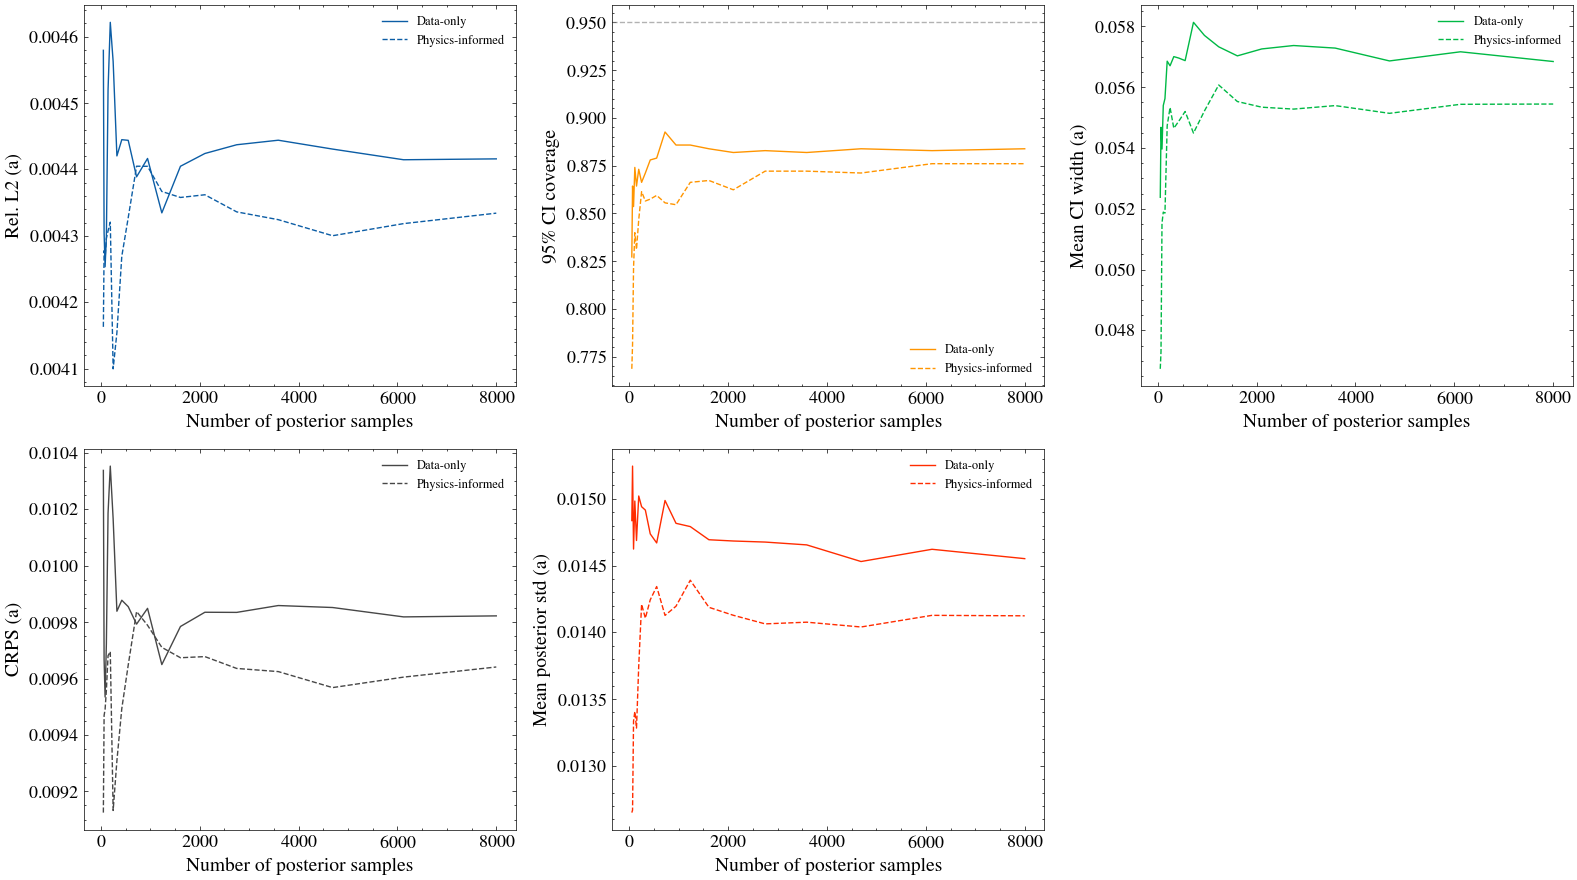

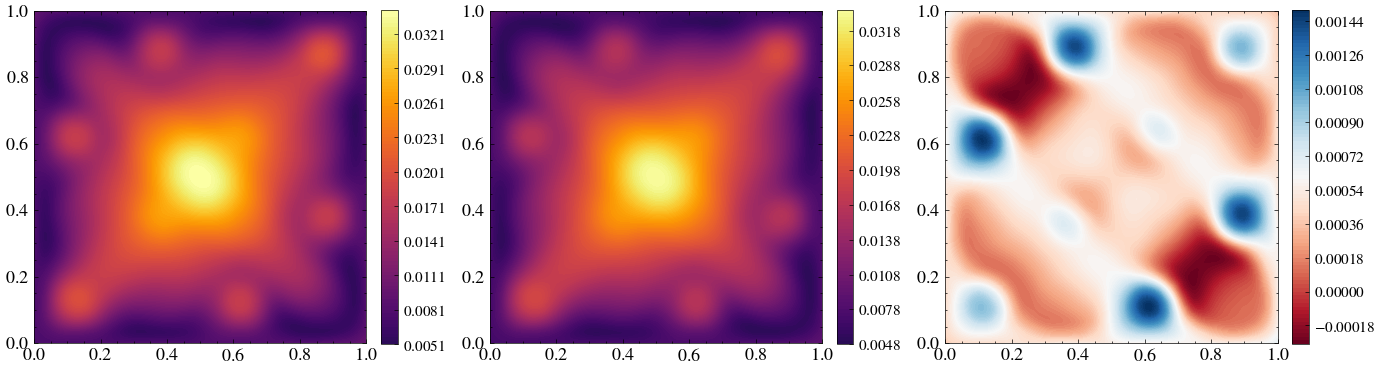

/workspace/experiments/experiment_utils/_plotting.py:576: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, framealpha=0.3, facecolor='white', edgecolor='black')


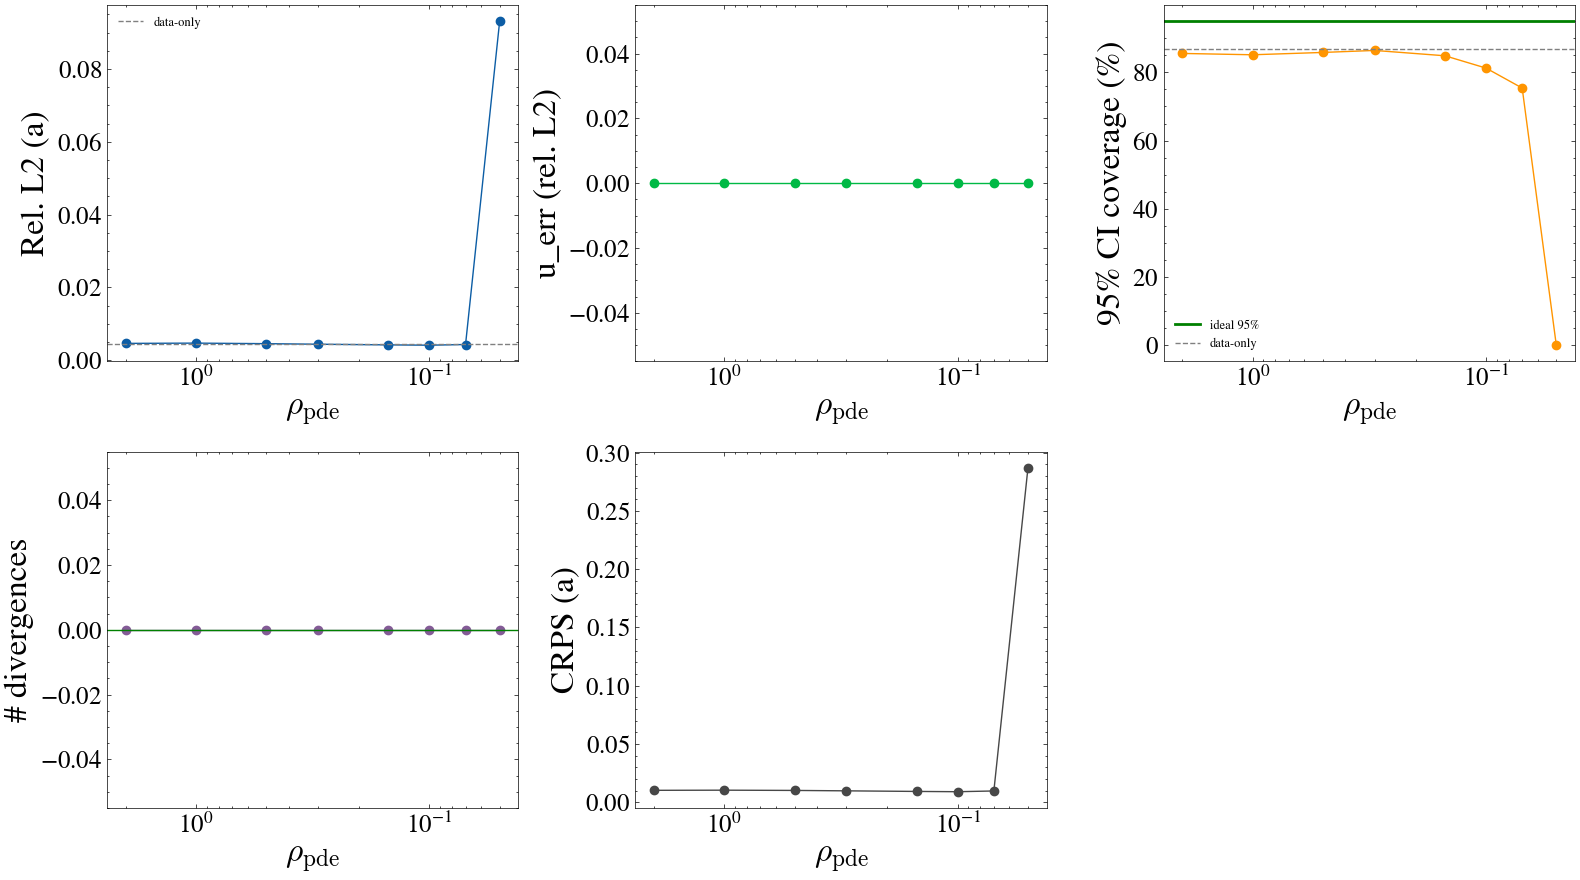

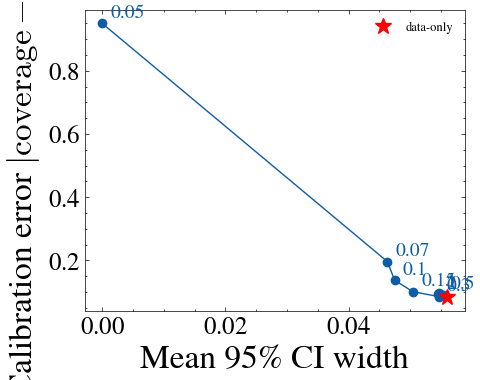

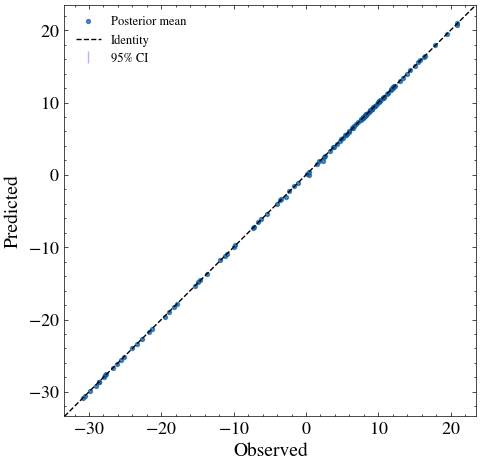

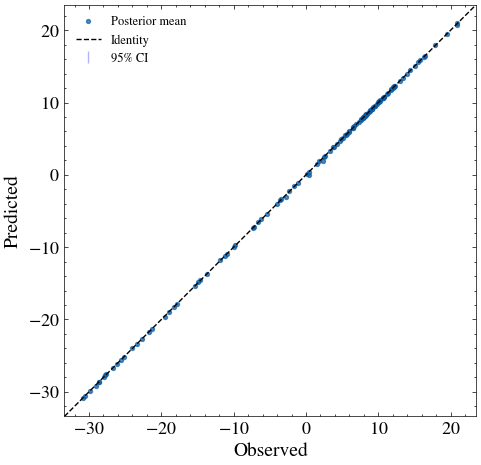

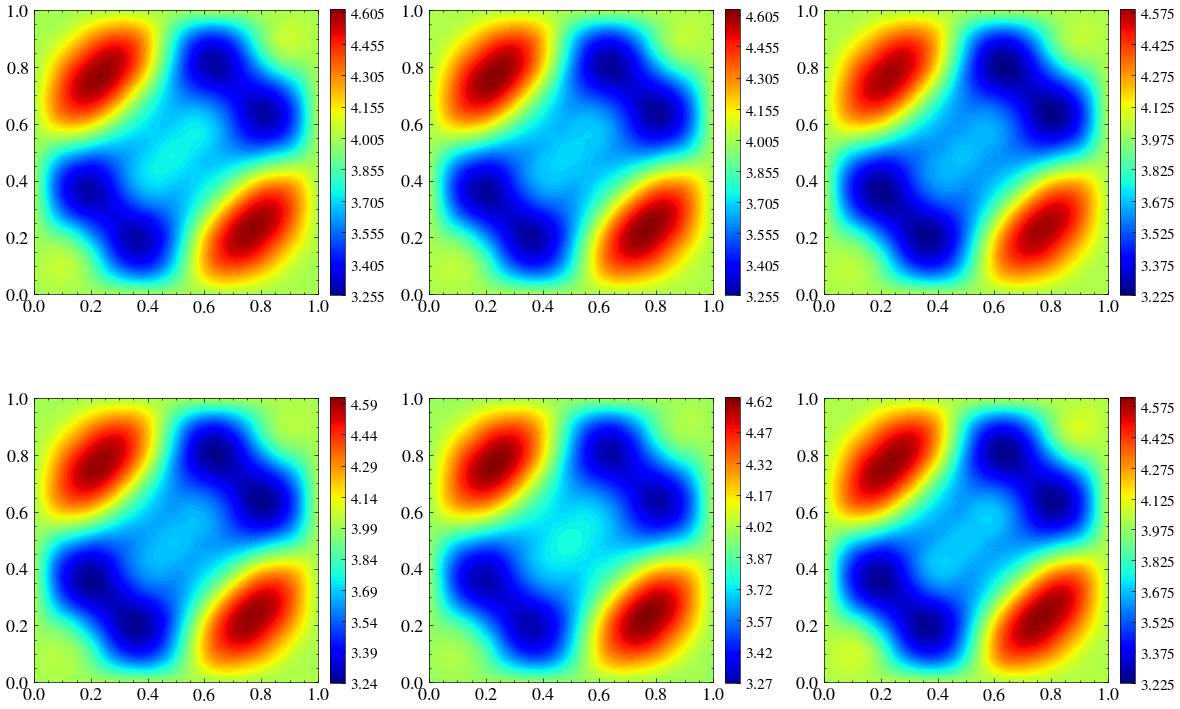

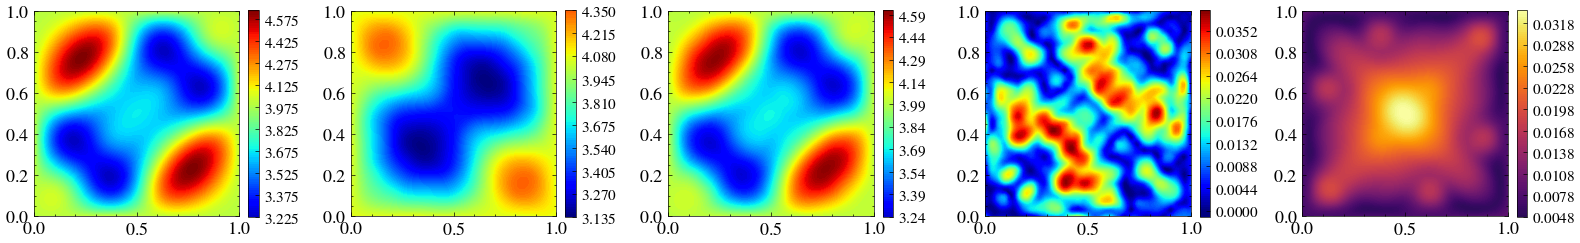


  RELIABILITY (physics): [PASS] All diagnostics within thresholds
  RELIABILITY (data-only): [PASS] All diagnostics within thresholds


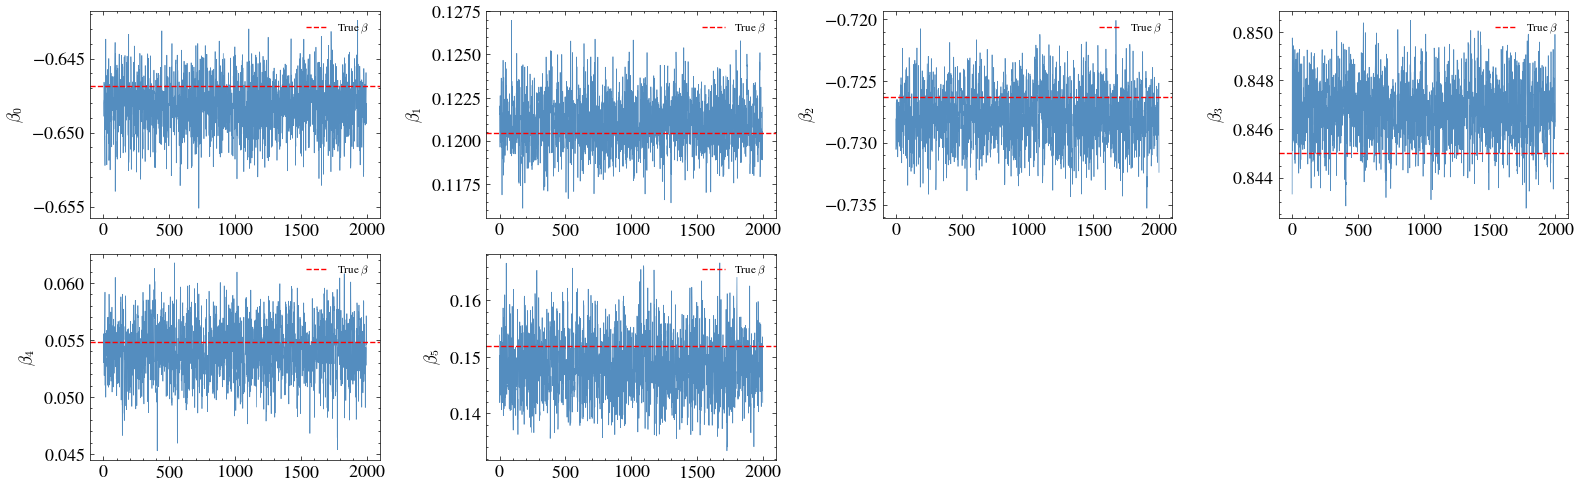

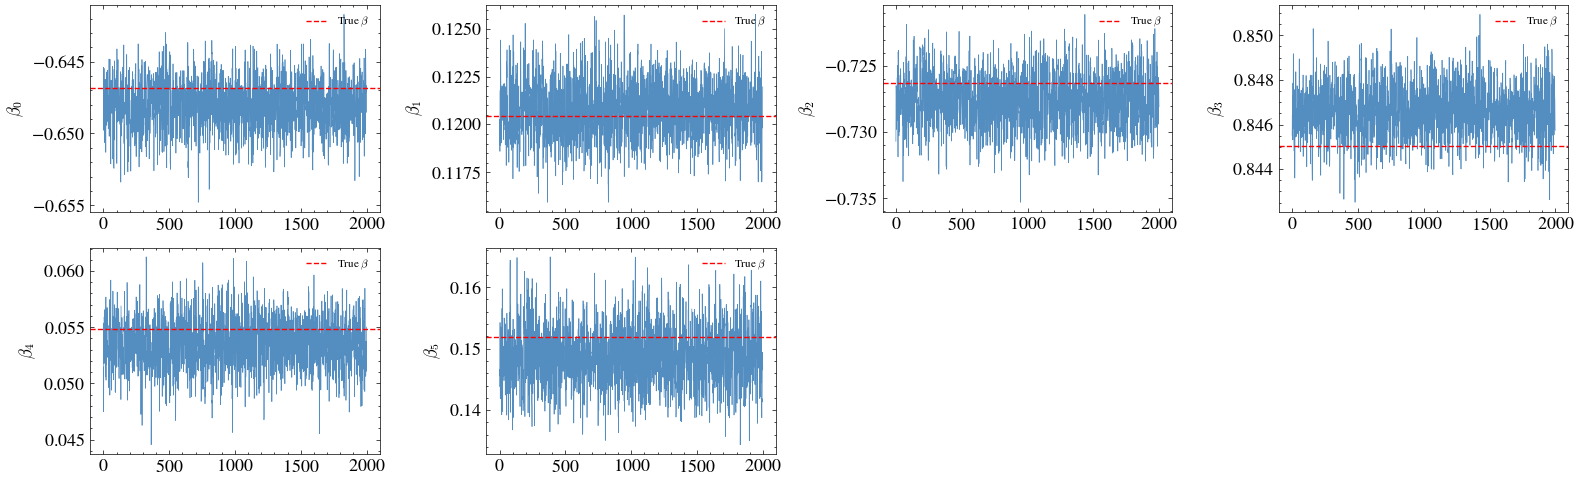

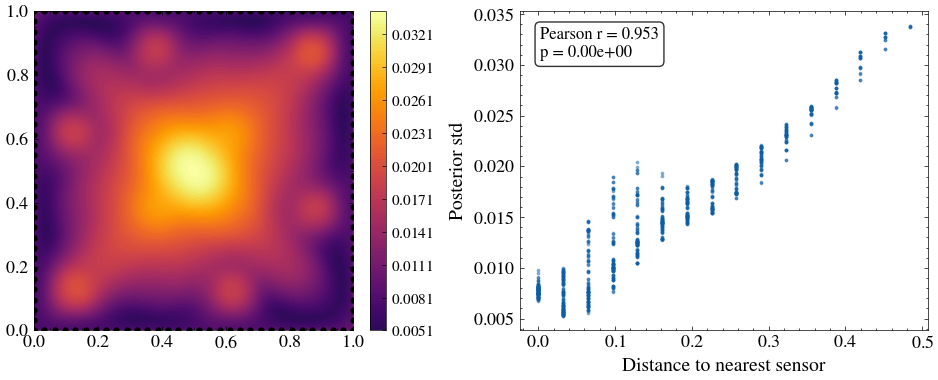

Spearman rho (data-only): 0.341, p = 2.94e-29
Spearman rho (physics): 0.352, p = 2.66e-31


In [13]:
from results_schema import ExperimentResult
from datetime import datetime

for SEED in SEEDS:
    _t_total_start = time.time()
    print(f"\n{'='*70}")
    print(f"SEED = {SEED}")
    print(f"{'='*70}")

    rng = random.PRNGKey(SEED)
    rng, key = random.split(rng)

    FIGURE_DIR = Path(f'figures/physics_eit/test{TEST_IDX}/seed{SEED}')
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    # ---- Observations ----
    obs_indices = problem.sample_observation_indices(n_points, N_OBS, 'random', key)
    obs_data = problem.prepare_observations(
        sample_indices=[TEST_IDX], obs_indices=obs_indices,
    )
    x_full = obs_data['x_full']
    x_obs = obs_data['x_obs']
    u_obs = obs_data['u_obs']
    a_true = obs_data['a_true']
    g_l = obs_data['g_l']
    u_true = obs_data.get('u_true', None)
    a_true_np = np.array(a_true[0, :, 0])

    n_bd = x_obs.shape[1]
    normals = problem._active_boundary_normals_jax

    # ---- Prior Predictive ----
    prior_a_samples, prior_metrics, rng = sample_unconditional_prior(
        problem, params, x_full, a_true_np, rng,
    )
    print(f"Prior predictive: a_err={prior_metrics['a_err']:.4f}, "
          f"CRPS={prior_metrics['crps_a']:.4f}, cov95={prior_metrics['coverage_95']:.4f}")

    # ---- Build per-seed models ----
    log_likelihood_fn = _make_eit_log_likelihood(x_obs, u_obs, normals)
    numpyro_model_data_only = make_numpyro_model(d, log_prior_fn, log_likelihood_fn, sample_name=SAMPLE_NAME)
    numpyro_model_physics = make_numpyro_model_physics(d, log_prior_fn, log_likelihood_fn, log_pde_fn, sample_name=SAMPLE_NAME)

    # ---- MAP Baseline ----
    map_result = run_map_estimation(problem, params, x_obs, u_obs, x_full, inv_config, rng)
    beta_map = map_result['beta_map']
    a_map = map_result['a_map']
    _map_time_s = map_result['time_s']
    rng = map_result['rng']

    rmse_map_a = rmse(a_map, a_true[0])
    print(f"\nMAP RMSE (a): {rmse_map_a:.6f}")

    from src.utils.PlotFigure import Plot
    h = map_result['loss_history']
    Plot.show_loss(
        [h['total'], h['weighted_pde'], h['weighted_data']],
        ['Total', f'PDE (x{inv_config.loss_weights.pde})', f'Data (x{inv_config.loss_weights.data})'],
        save_path=str(FIGURE_DIR / 'map_loss_curves.png'),
    )

    # ---- Data-Only MCMC Full Run ----
    print(f"Data-only MCMC: {NUM_WARMUP} warmup, {NUM_SAMPLES} samples, sigma={SIGMA}, {NUM_CHAINS} chains ({CHAIN_METHOD})")

    nuts_cfg = recommended_nuts_config(d, SIGMA)
    rng, mcmc_key = random.split(rng)
    mcmc_do, timing_do = run_mcmc(
        numpyro_model_data_only, {SAMPLE_NAME: beta_a_mode}, {"sigma": SIGMA}, mcmc_key,
        NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS, CHAIN_METHOD, nuts_cfg,
    )
    mcmc_do.print_summary()

    diag_do = extract_mcmc_diagnostics(mcmc_do, sample_name=SAMPLE_NAME, total_samples=NUM_CHAINS * NUM_SAMPLES)

    # Decode coefficient (a decoder uses beta_a only)
    n_do = diag_do['samples'].shape[0]
    x_tiled = jnp.tile(x_full, (n_do, 1, 1))
    a_pred_do = problem.models['a'].apply({'params': params['a']}, x_tiled, diag_do['samples'])
    a_pred_do = a_pred_do[..., None] if a_pred_do.ndim == 2 else a_pred_do

    a_do_np = np.array(a_pred_do[:, :, 0])
    a_std_do = np.std(a_do_np, axis=0)

    metrics_do = compute_standard_metrics(a_do_np, a_true_np)

    print(f"Data-only: a_err={metrics_do['a_err']:.4f}  "
          f"coverage={metrics_do['coverage_95']:.2%}  CRPS={metrics_do['crps_a']:.6f}")

    # ---- Physics-Informed Full Run ----
    print(f"Physics MCMC: rho_pde={BEST_RHO_PDE}, {NUM_WARMUP} warmup, {NUM_SAMPLES} samples, {NUM_CHAINS} chains")

    rng, mcmc_key_phys = random.split(rng)
    mcmc_phys, timing_phys = run_mcmc(
        numpyro_model_physics, {SAMPLE_NAME: beta_a_mode},
        {"sigma": SIGMA, "rho_pde": BEST_RHO_PDE}, mcmc_key_phys,
        NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS, CHAIN_METHOD, nuts_cfg,
    )

    diag_phys = extract_mcmc_diagnostics(mcmc_phys, sample_name=SAMPLE_NAME, total_samples=NUM_CHAINS * NUM_SAMPLES)

    n_phys = diag_phys['samples'].shape[0]
    x_tiled_phys = jnp.tile(x_full, (n_phys, 1, 1))
    a_pred_phys = problem.models['a'].apply({'params': params['a']}, x_tiled_phys, diag_phys['samples'])
    a_pred_phys = a_pred_phys[..., None] if a_pred_phys.ndim == 2 else a_pred_phys

    a_phys_np = np.array(a_pred_phys[:, :, 0])
    a_std_phys = np.std(a_phys_np, axis=0)

    metrics_phys = compute_standard_metrics(a_phys_np, a_true_np)

    print(f"Physics: a_err={metrics_phys['a_err']:.4f}  "
          f"coverage={metrics_phys['coverage_95']:.2%}  CRPS={metrics_phys['crps_a']:.6f}")

    # ---- Chi2 PPC (Neumann flux) ----
    def compute_neumann_for_beta(beta_a_single):
        beta_b = beta_a_single[None, :]
        g_l_onehot_s = one_hot_g_l(problem._current_g_l)
        beta_u = jnp.concatenate([beta_b, g_l_onehot_s], axis=-1)
        g_l_scalar = problem._current_g_l[0, 0]
        _, du_vals = compute_u_and_grad_eit(
            params['u'], problem.models['u'], x_obs[0], beta_u[0], g_l_scalar
        )
        a_vals = problem.models['a'].apply({'params': params['a']}, x_obs, beta_b)[0]
        return a_vals * (du_vals[:, 0] * normals[:, 0] + du_vals[:, 1] * normals[:, 1])

    n_pred = min(100, n_do)
    pred_idx_do = np.linspace(0, n_do - 1, n_pred, dtype=int)
    flux_pred_do = np.stack(
        [np.array(compute_neumann_for_beta(diag_do['samples'][idx])) for idx in pred_idx_do], axis=0
    )

    beta_a_phys = diag_phys['samples']
    n_pred_phys = min(100, n_phys)
    pred_idx_phys = np.linspace(0, n_phys - 1, n_pred_phys, dtype=int)
    flux_pred_phys = np.stack(
        [np.array(compute_neumann_for_beta(beta_a_phys[idx])) for idx in pred_idx_phys], axis=0
    )

    neumann_obs_np = np.array(u_obs[0, :, 0])
    chi2_do, pval_do = chi2_ppc(neumann_obs_np, flux_pred_do, SIGMA)
    chi2_phys, pval_phys = chi2_ppc(neumann_obs_np, flux_pred_phys, SIGMA)
    print(f"  Chi2 PPC (data-only): chi2={chi2_do:.2f}, p={pval_do:.4f}")
    print(f"  Chi2 PPC (physics):   chi2={chi2_phys:.2f}, p={pval_phys:.4f}")

    # ---- Spearman error-std correlation ----
    spearman_rho_do, spearman_p_do = compute_error_std_correlation(
        a_true_np, a_do_np.mean(axis=0), a_std_do)
    spearman_rho_phys, spearman_p_phys = compute_error_std_correlation(
        a_true_np, a_phys_np.mean(axis=0), a_std_phys)

    # ---- Save Results ----
    sharpness_do = float(np.mean(a_std_do))
    sharpness_phys = float(np.mean(a_std_phys))

    do_result = {
        "sigma": SIGMA, "label": "data_only",
        "ess_min": diag_do['ess_min'], "rhat_max": diag_do['rhat_max'],
        "rhat_mean": diag_do['rhat_mean'], "n_div": diag_do['n_div'],
        "reliability_flag": diag_do['flag'],
        "reliability_explanation": diag_do['flag_explanation'],
        "a_err": metrics_do['a_err'],
        "crps_a": metrics_do['crps_a'], "nll_a": metrics_do['nll_a'],
        "coverage": metrics_do['coverage_95'],
        "ci_width": metrics_do['ci_width'], "mean_std": sharpness_do,
        "cal_levels": metrics_do['cal_levels'],
        "cal_empirical": metrics_do['cal_empirical'],
        "chi2_ppc": chi2_do, "chi2_ppc_pvalue": pval_do,
        "map_a_err": float(rmse_map_a),
        "spearman_rho_error_std": float(spearman_rho_do),
        "spearman_pvalue_error_std": float(spearman_p_do),
        "warmup_time_s": timing_do['warmup_time_s'],
        "sampling_time_s": timing_do['sampling_time_s'],
        "step_time_s": timing_do['step_time_s'],
    }

    phys_result = {
        "sigma": SIGMA, "label": "physics",
        "ess_min": diag_phys['ess_min'], "rhat_max": diag_phys['rhat_max'],
        "rhat_mean": diag_phys['rhat_mean'], "n_div": diag_phys['n_div'],
        "reliability_flag": diag_phys['flag'],
        "reliability_explanation": diag_phys['flag_explanation'],
        "a_err": metrics_phys['a_err'],
        "crps_a": metrics_phys['crps_a'], "nll_a": metrics_phys['nll_a'],
        "coverage": metrics_phys['coverage_95'],
        "ci_width": metrics_phys['ci_width'], "mean_std": sharpness_phys,
        "cal_levels": metrics_phys['cal_levels'],
        "cal_empirical": metrics_phys['cal_empirical'],
        "chi2_ppc": chi2_phys, "chi2_ppc_pvalue": pval_phys,
        "map_a_err": float(rmse_map_a),
        "spearman_rho_error_std": float(spearman_rho_phys),
        "spearman_pvalue_error_std": float(spearman_p_phys),
        "warmup_time_s": timing_phys['warmup_time_s'],
        "sampling_time_s": timing_phys['sampling_time_s'],
        "step_time_s": timing_phys['step_time_s'],
    }

    experiment = ExperimentResult(
        experiment="physics",
        problem="eit",
        experiment_type="comparison",
        seed=SEED,
        test_idx=TEST_IDX,
        timestamp=datetime.now().strftime("%Y-%m-%dT%H:%M:%S"),
        conditions={
            "data_only": build_mcmc_result(do_result, NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS),
            "physics": build_mcmc_result(phys_result, NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS),
        },
        prior=build_prior_result(prior_metrics),
        map_time_s=_map_time_s,
        total_time_s=time.time() - _t_total_start,
    )

    out_path = save_experiment_result(experiment)
    print(f"Saved structured result to: {out_path}")


    # ---- Plots ----
    x_np = np.array(x_full[0])

    plot_metrics_comparison_table(
        {
            'RMSE (a)': float(rmse(jnp.array(np.mean(a_do_np, axis=0)), jnp.array(a_true_np))),
            'Rel. L2 (a)': metrics_do['a_err'],
            'CRPS (a)': metrics_do['crps_a'],
            '95% Coverage': metrics_do['coverage_95'],
            'CI Width (a)': metrics_do['ci_width'],
            'Sharpness (mean std)': sharpness_do,
            'ESS min': diag_do['ess_min'],
            'Divergences': diag_do['n_div'],
        },
        {
            'RMSE (a)': float(rmse(jnp.array(np.mean(a_phys_np, axis=0)), jnp.array(a_true_np))),
            'Rel. L2 (a)': metrics_phys['a_err'],
            'CRPS (a)': metrics_phys['crps_a'],
            '95% Coverage': metrics_phys['coverage_95'],
            'CI Width (a)': metrics_phys['ci_width'],
            'Sharpness (mean std)': sharpness_phys,
            'ESS min': diag_phys['ess_min'],
            'Divergences': diag_phys['n_div'],
        },
        title=f'EIT seed={SEED} (sigma={SIGMA}, rho_pde={BEST_RHO_PDE})',
    )

    # Significance Tests
    def _crps_a(s, t): return float(np.mean(crps_ensemble(s, t)))
    def _coverage_95(s, t):
        _, emp = compute_calibration(s, t, np.array([0.95]))
        return float(emp[0])
    def _ci_width(s, t): return ci_width_95(s)

    rng_bs = np.random.default_rng(SEED)
    diff_crps_a = bootstrap_metric_difference_ci(a_do_np, a_phys_np, a_true_np, _crps_a, rng=rng_bs)
    diff_cov = bootstrap_metric_difference_ci(a_do_np, a_phys_np, a_true_np, _coverage_95, rng=rng_bs)
    diff_width = bootstrap_metric_difference_ci(a_do_np, a_phys_np, a_true_np, _ci_width, rng=rng_bs)

    format_significance_table({
        'CRPS (a) diff (DO - Phys)': diff_crps_a,
        'Coverage 95% diff (DO - Phys)': diff_cov,
        'CI Width diff (DO - Phys)': diff_width,
    }, title=f'EIT seed={SEED} -- RQ2: Physics vs Data-Only (Bootstrap)')

    # Metric Convergence
    conv_do = compute_metric_convergence(a_do_np, a_true_np)
    conv_phys = compute_metric_convergence(a_phys_np, a_true_np)
    plot_metric_convergence(
        [conv_do, conv_phys],
        labels=['Data-only', 'Physics-informed'],
        save_path=FIGURE_DIR / 'metric_convergence.png',
    )

    plot_std_comparison(
        x_np,
        std_data_only=a_std_do,
        std_physics=a_std_phys,
        grid_shape=(32, 32),
        save_path=FIGURE_DIR / 'std_comparison.png',
    )

    plot_rho_sweep(
        sweep_results, _sweep_data_only_baseline,
        save_path=FIGURE_DIR / 'rho_sweep.png',
    )

    plot_sharpness_calibration_tradeoff(
        sweep_results, _sweep_data_only_baseline,
        save_path=FIGURE_DIR / 'sharpness_calibration_tradeoff.png',
    )

    with plt.style.context(_use_science_style()):
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Ideal')
        ax.plot(metrics_do['cal_levels'], metrics_do['cal_empirical'], 'o-', markersize=6, label='Data-only')
        ax.plot(metrics_phys['cal_levels'], metrics_phys['cal_empirical'], 's-', markersize=6, label='Physics-informed')
        ax.set_xlabel('Nominal Coverage', fontsize=14)
        ax.set_ylabel('Empirical Coverage', fontsize=14)
        ax.tick_params(labelsize=13)
        ax.set_xlim(0.4, 1.0)
        ax.set_ylim(0.4, 1.05)
        ax.legend(fontsize=9, framealpha=0.3, facecolor='white', edgecolor='black')
        plt.tight_layout()
        fig.savefig(FIGURE_DIR / 'calibration_overlay.png', dpi=200, bbox_inches='tight')
        plt.close(fig)

    plot_posterior_predictive(
        neumann_obs_np, flux_pred_do,
        obs_label='Neumann flux observed',
        save_path=FIGURE_DIR / 'posterior_predictive_data_only.png',
    )
    plot_posterior_predictive(
        neumann_obs_np, flux_pred_phys,
        obs_label='Neumann flux observed',
        save_path=FIGURE_DIR / 'posterior_predictive_physics.png',
    )

    plot_posterior_gallery(
        x_np, a_phys_np, grid_shape=(32, 32),
        a_true=a_true_np, n_show=6,
        save_path=FIGURE_DIR / 'posterior_gallery_physics.png',
    )

    a_map_np = np.array(a_map[:, 0])
    plot_field_comparison(
        x_np, a_true_np, a_map_np, a_phys_np.mean(axis=0), a_std_phys,
        grid_shape=(32, 32),
        obs_coords=np.array(x_obs[0]),
        save_path=FIGURE_DIR / 'field_comparison_physics.png',
    )

    # Diagnostics
    print_dimension_diagnostics = lambda s, e, r: None  # noqa: already printed by extract
    print(f"\n  RELIABILITY (physics): [{diag_phys['flag']}] {diag_phys['flag_explanation']}")
    print(f"  RELIABILITY (data-only): [{diag_do['flag']}] {diag_do['flag_explanation']}")

    beta_true = problem.models['enc'].apply({'params': params['enc']}, a_true)[0]
    beta_true_np = np.array(beta_true)

    beta_all_chains_do = np.array(mcmc_do.get_samples(group_by_chain=True)[SAMPLE_NAME])
    plot_trace(beta_all_chains_do[0], beta_true_np, num_warmup=0,
               save_path=FIGURE_DIR / 'trace_plots_data_only.png')

    beta_phys_by_chain = np.array(mcmc_phys.get_samples(group_by_chain=True)[SAMPLE_NAME])
    plot_trace(beta_phys_by_chain[0], beta_true_np,
               save_path=FIGURE_DIR / 'trace_plots_physics.png')

    plot_uncertainty_investigation(
        x_np, a_std_do, np.array(x_obs[0]),
        grid_shape=(32, 32),
        save_path=FIGURE_DIR / 'uncertainty_investigation.png',
    )

    spearman_rho_do, spearman_p_do = compute_error_std_correlation(
        a_true_np, a_do_np.mean(axis=0), a_std_do,
        save_path=FIGURE_DIR / 'error_vs_std_data_only.png',
    )
    print(f'Spearman rho (data-only): {spearman_rho_do:.3f}, p = {spearman_p_do:.2e}')

    spearman_rho_phys, spearman_p_phys = compute_error_std_correlation(
        a_true_np, a_phys_np.mean(axis=0), a_std_phys,
        save_path=FIGURE_DIR / 'error_vs_std_physics.png',
    )
    print(f'Spearman rho (physics): {spearman_rho_phys:.3f}, p = {spearman_p_phys:.2e}')

## Cross-Seed Aggregation Summary

In [14]:
results = load_cross_seed_results("physics", "eit")
if len(results) > 1:
    print(f"Cross-Seed Summary ({len(results)} seeds: {[r.seed for r in results]})")
    for cond in list(results[0].conditions.keys()):
        print(f"\n--- {cond} ---")
        print(f"{'Metric':<16s}  {'Mean':>10s}  {'Std':>10s}  {'Min':>10s}  {'Max':>10s}")
        print("-" * 62)
        for m in ["a_err", "u_err", "crps_a", "nll_a", "coverage_95", "ci_width", "mean_std", "ess_min", "rhat_max", "n_div"]:
            try:
                s = cross_seed_metric_summary(results, metric=m, condition_key=cond)
                if s["mean"] is not None:
                    print(f"{m:<16s}  {s['mean']:>10.4f}  {s['std']:>10.4f}  {s['min']:>10.4f}  {s['max']:>10.4f}")
            except (AttributeError, KeyError, TypeError):
                pass
else:
    print(f"Only {len(results)} seed result(s) found - skipping cross-seed summary")

Cross-Seed Summary (15 seeds: [7, 7, 7, 42, 42, 42, 42, 42, 42, 123, 123, 123, 123, 123, 123])

--- data_only ---
Metric                  Mean         Std         Min         Max
--------------------------------------------------------------
a_err                 0.0088      0.0106      0.0040      0.0363
u_err                    nan         nan         nan         nan
crps_a                0.0144      0.0094      0.0097      0.0397
nll_a                -2.2985      0.5491     -2.5876     -0.9186
coverage_95           0.9520      0.0510      0.8799      0.9951
ci_width              0.1357      0.1291      0.0568      0.4668
mean_std              0.0414      0.0505      0.0145      0.1708
ess_min            3281.9388   1927.7821      2.0070   5734.7225
rhat_max              2.7221      4.6481      1.0003     16.5220
n_div                 5.8667      7.1601      0.0000     20.0000

--- physics ---
Metric                  Mean         Std         Min         Max
--------------------------